In [14]:
import json, os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

with open("../data/processed/processed_resumes.json") as f:
    resumes = json.load(f)

df = pd.DataFrame(resumes)
print(df.shape)
print(df['category'].unique())
df.head()

(2484, 9)
<StringArray>
[                    'HR',               'DESIGNER', 'INFORMATION-TECHNOLOGY',
                'TEACHER',               'ADVOCATE',   'BUSINESS-DEVELOPMENT',
             'HEALTHCARE',                'FITNESS',            'AGRICULTURE',
                    'BPO',                  'SALES',             'CONSULTANT',
          'DIGITAL-MEDIA',             'AUTOMOBILE',                   'CHEF',
                'FINANCE',                'APPAREL',            'ENGINEERING',
             'ACCOUNTANT',           'CONSTRUCTION',       'PUBLIC-RELATIONS',
                'BANKING',                   'ARTS',               'AVIATION']
Length: 24, dtype: str


,filename,raw_text,email,phone,skills,experience_years,education,skill_count,category
0,resume_0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,,,"[swift, data analysis]",15,be,2,HR
1,resume_1,"HR SPECIALIST, US HR OPERATIONS ...",,,"[photoshop, illustrator]",0,bachelor of arts,2,HR
2,resume_2,HR DIRECTOR Summary Over 2...,,,"[express, excel]",20,bachelor of science,2,HR
3,resume_3,HR SPECIALIST Summary Dedica...,,,[excel],20,not specified,1,HR
4,resume_4,HR MANAGER Skill Highlights ...,,,[excel],0,be,1,HR


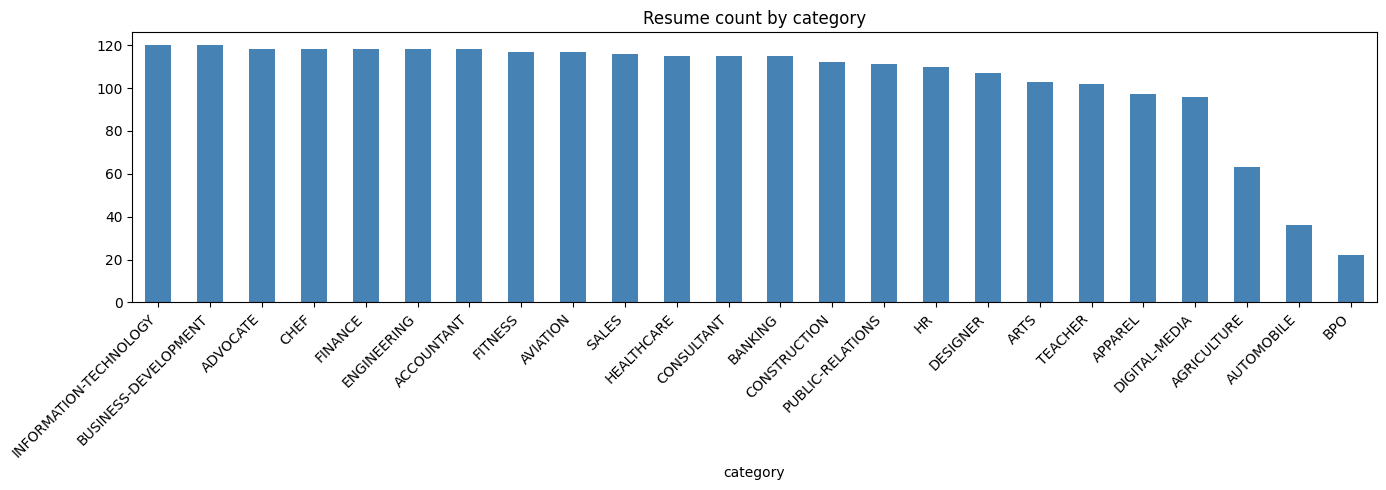

In [15]:
plt.figure(figsize=(14, 5))
df['category'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Resume count by category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../reports/category_distribution.png")
plt.show()

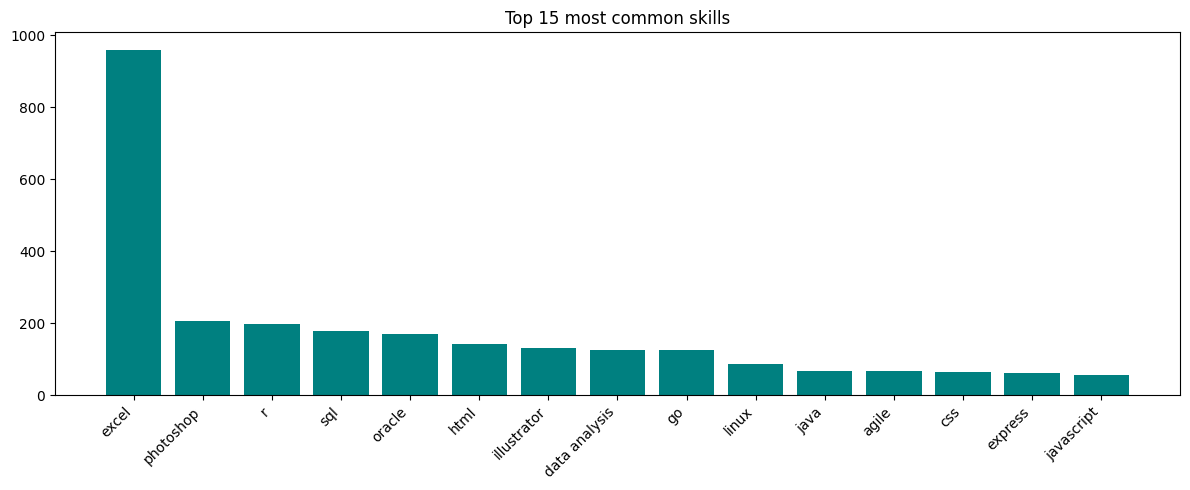

In [16]:
all_skills = []
for skills in df['skills']:
    all_skills.extend(skills)

skill_counts = Counter(all_skills).most_common(15)
skills_list, counts = zip(*skill_counts)

plt.figure(figsize=(12, 5))
plt.bar(skills_list, counts, color='teal')
plt.title("Top 15 most common skills")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../reports/top_skills.png")
plt.show()

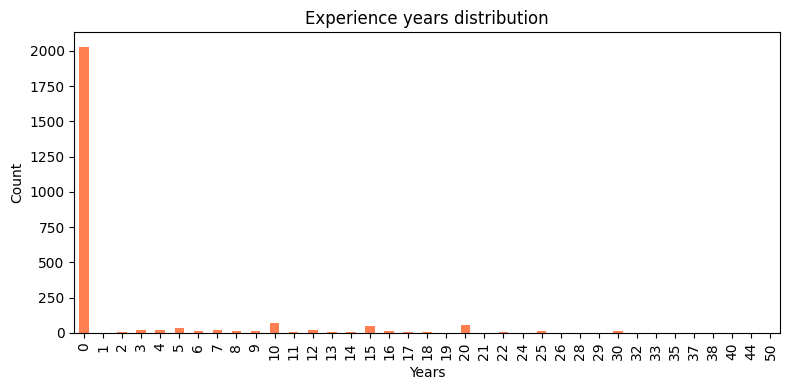

In [17]:
plt.figure(figsize=(8, 4))
df['experience_years'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.title("Experience years distribution")
plt.xlabel("Years")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/experience_distribution.png")
plt.show()

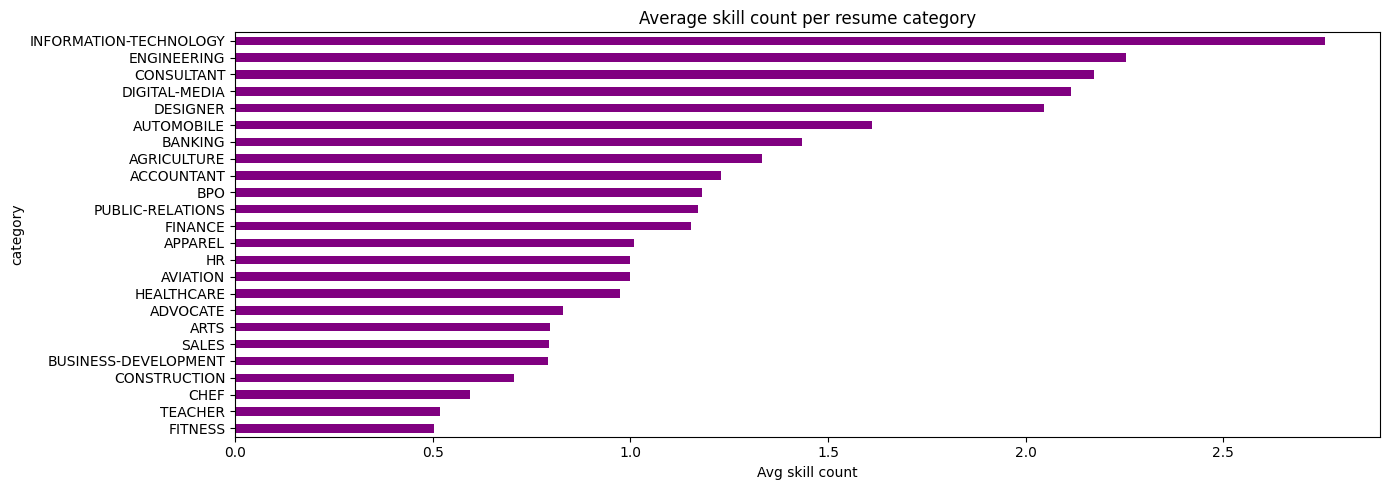

In [18]:
plt.figure(figsize=(14, 5))
df.groupby('category')['skill_count'].mean().sort_values().plot(kind='barh', color='purple')
plt.title("Average skill count per resume category")
plt.xlabel("Avg skill count")
plt.tight_layout()
plt.savefig("../reports/skills_per_category.png")
plt.show()

In [27]:
import json

with open("../models/eval_results.json") as f:
    results = json.load(f)

print("=== Model Comparison ===\n")
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f"  Accuracy : {metrics['accuracy']:.4f}")
    print(f"  CV F1    : {metrics['cv_f1_mean']:.4f} ± {metrics['cv_f1_std']:.4f}")
    print()

# Bias check — does skill_count vary by category in a way that could unfairly rank?
print("=== Potential bias check ===")
print("Categories with lowest average skill count (may be disadvantaged in ranking):")
print(df.groupby('category')['skill_count'].mean().sort_values().head(5))
print()
print("Categories with highest average skill count (may be advantaged):")
print(df.groupby('category')['skill_count'].mean().sort_values().tail(5))

=== Model Comparison ===

logistic_regression:
  Accuracy : 0.6660
  CV F1    : 0.6405 ± 0.0425

random_forest:
  Accuracy : 0.7646
  CV F1    : 0.7196 ± 0.0576

=== Potential bias check ===
Categories with lowest average skill count (may be disadvantaged in ranking):
category
FITNESS                 0.504274
TEACHER                 0.519608
CHEF                    0.593220
CONSTRUCTION            0.705357
BUSINESS-DEVELOPMENT    0.791667
Name: skill_count, dtype: float64

Categories with highest average skill count (may be advantaged):
category
DESIGNER                  2.046729
DIGITAL-MEDIA             2.114583
CONSULTANT                2.173913
ENGINEERING               2.254237
INFORMATION-TECHNOLOGY    2.758333
Name: skill_count, dtype: float64


In [28]:
import json
import pandas as pd

with open("../models/eval_results.json") as f:
    results = json.load(f)

print("=== Model Comparison ===\n")
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f"  Accuracy : {metrics['accuracy']:.4f}")
    print(f"  CV F1    : {metrics['cv_f1_mean']:.4f} ± {metrics['cv_f1_std']:.4f}")
    print()

import json, os
with open("../data/processed/processed_resumes.json") as f:
    resumes = json.load(f)

df = pd.DataFrame(resumes)

print("=== Potential bias check ===")
print("Categories with LOWEST avg skill count (may be disadvantaged):")
print(df.groupby('category')['skill_count'].mean().sort_values().head(5))
print()
print("Categories with HIGHEST avg skill count (may be advantaged):")
print(df.groupby('category')['skill_count'].mean().sort_values().tail(5))

=== Model Comparison ===

logistic_regression:
  Accuracy : 0.6660
  CV F1    : 0.6405 ± 0.0425

random_forest:
  Accuracy : 0.7646
  CV F1    : 0.7196 ± 0.0576

=== Potential bias check ===
Categories with LOWEST avg skill count (may be disadvantaged):
category
FITNESS                 0.504274
TEACHER                 0.519608
CHEF                    0.593220
CONSTRUCTION            0.705357
BUSINESS-DEVELOPMENT    0.791667
Name: skill_count, dtype: float64

Categories with HIGHEST avg skill count (may be advantaged):
category
DESIGNER                  2.046729
DIGITAL-MEDIA             2.114583
CONSULTANT                2.173913
ENGINEERING               2.254237
INFORMATION-TECHNOLOGY    2.758333
Name: skill_count, dtype: float64
